# NETWORK MODELING FOR INFECTIOUS DISEASE SPREAD





- Temporal Modeling - Temporal Convolutional Neural Network (TCN)

In [1]:
%pip install keras-tcn

INFO: pip is looking at multiple versions of keras-tcn to determine which version is compatible with other requirements. This could take a while.


In [2]:
import pandas as pd
import numpy as np
import random
import torch

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from tcn import TCN

def set_seed(seed=11):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(11)

# Data Preparation

In [3]:
# Loading merged dataset
df = pd.read_csv("df_high_burden.csv")
# Data Overview
df.head()

,state,county,year,MMWR WEEK,Label,previous_52_week_max,latitude,longitude,population_estimate,income,Label_grouped,Disease_Group
0,ALABAMA,Chilton,2022,1,"Arboviral diseases, West Nile virus disease",2,32.756889,-86.844516,45868.0,43434.0,Arboviral diseases,Vector-borne
1,ALABAMA,Chilton,2022,1,Campylobacteriosis,39,32.756889,-86.844516,45868.0,43434.0,Campylobacteriosis,Enteric
2,ALABAMA,Chilton,2022,1,Coccidioidomycosis,2,32.756889,-86.844516,45868.0,43434.0,Coccidioidomycosis,Fungal
3,ALABAMA,Chilton,2022,1,Cryptosporidiosis,7,32.756889,-86.844516,45868.0,43434.0,Cryptosporidiosis,Enteric
4,ALABAMA,Chilton,2022,1,Cyclosporiasis,3,32.756889,-86.844516,45868.0,43434.0,Cyclosporiasis,Enteric


In [4]:
# Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158195 entries, 0 to 158194
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   state                 158195 non-null  object 
 1   county                158195 non-null  object 
 2   year                  158195 non-null  int64  
 3   MMWR WEEK             158195 non-null  int64  
 4   Label                 158195 non-null  object 
 5   previous_52_week_max  158195 non-null  int64  
 6   latitude              158195 non-null  float64
 7   longitude             158194 non-null  float64
 8   population_estimate   158194 non-null  float64
 9   income                158194 non-null  float64
 10  Label_grouped         158194 non-null  object 
 11  Disease_Group         158194 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 14.5+ MB


In [5]:
# Log Transformation for Target
df["previous_52_week_max"]= np.log1p(df["previous_52_week_max"].values).astype(np.float32)

# Sorting Data by State, County, Label, Year, and MMWR Week
df = df.sort_values(
    ["state", "county", "Disease_Group", "year", "MMWR WEEK"]
).reset_index(drop=True)

## Encoding Categorical Variabes

In [6]:
# Encodings for state, county, and infection labels
state_enc = LabelEncoder()
county_enc = LabelEncoder()
infection_enc = LabelEncoder()

# Encoding Process
df["state_id"] = state_enc.fit_transform(df["state"])
df["county_id"] = county_enc.fit_transform(df["county"])
df["infection_id"] = infection_enc.fit_transform(df["Disease_Group"])

## Feature Engineering - Cyclical Encoding to Fix MMwR WEEK

Week 1 and Week 52 are next to each other and should be considered adjacent in the context of the spread of infections. Current int type places Week 1 and Week 2 far from each other.

In [7]:
# Cyclical encoding for MMWR WEEK

df["week_sin"] = np.sin(
    2 * np.pi * df["MMWR WEEK"] / 52
)

df["week_cos"] = np.cos(
    2 * np.pi * df["MMWR WEEK"] / 52
)

In [8]:
# Target and Creating Lags

target = "previous_52_week_max"

df["lag_1"] = df.groupby(["state", "county"])["previous_52_week_max"].shift(1)
df["lag_2"] = df.groupby(["state", "county"])["previous_52_week_max"].shift(2)
df["lag_3"] = df.groupby(["state", "county"])["previous_52_week_max"].shift(3)
df["lag_4"] = df.groupby(["state", "county"])["previous_52_week_max"].shift(4)

# Dropping NaNs
df = df.dropna()

# Temporal Convolutional Neural Network (TCN)

## Data Preprocessing

In [9]:
# Target variable and features
TARGET = "previous_52_week_max"

feature_cols = [
    "state_id",
    "county_id",
    "infection_id",
    "year",
    "week_sin",
    "week_cos",
    "latitude",
    "longitude",
    "population_estimate",
    "income",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4"
]

### Scaling Features

In [10]:
# Data Preprocessing: Scaling features
scaler = StandardScaler()

df[feature_cols] = scaler.fit_transform(
    df[feature_cols]
)

### Temporal Sequences

In [11]:
SEQ_LEN = 4

X = []
y = []

group_cols = ["state", "county", "Label"]

for _, grp in df.groupby(group_cols):

    # Keep original dataframe order
    features = grp[feature_cols].values
    target = grp[TARGET].values

    if len(grp) <= SEQ_LEN:
        continue

    for i in range(len(grp) - SEQ_LEN):

        X.append(features[i:i + SEQ_LEN])
        y.append(target[i + SEQ_LEN])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (148204, 4, 14)
y shape: (148204,)


### Data Partitioning

In [12]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## TCN Model

In [13]:
# Model Architecture: TCN with Dense layers
model = Sequential([

    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8, 16, 32],
        dropout_rate=0.2,
        return_sequences=False,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(1)
])

# Model Compilation
model.compile(
    optimizer=Adam(1e-3),
    loss="mse",
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

# Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │       139,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,225 (610.25 KB)

 Trainable params: 156,225 (610.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [14]:
# Model Training with Early Stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

# Training the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 70s 325ms/step - loss: 1.4260 - mae: 0.8906 - rmse: 1.1941 - val_loss: 1.2258 - val_mae: 0.8221 - val_rmse: 1.1071
Epoch 2/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 59s 317ms/step - loss: 0.8610 - mae: 0.7212 - rmse: 0.9279 - val_loss: 1.1185 - val_mae: 0.7914 - val_rmse: 1.0576
Epoch 3/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 331ms/step - loss: 0.7336 - mae: 0.6672 - rmse: 0.8565 - val_loss: 1.0063 - val_mae: 0.7551 - val_rmse: 1.0031
Epoch 4/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 58s 312ms/step - loss: 0.6497 - mae: 0.6282 - rmse: 0.8060 - val_loss: 0.7724 - val_mae: 0.6683 - val_rmse: 0.8789
Epoch 5/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 59s 318ms/step - loss: 0.5849 - mae: 0.5950 - rmse: 0.7648 - val_loss: 0.7705 - val_mae: 0.6720 - val_rmse: 0.8778
Epoch 6/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 58s 310ms/step - loss: 0.5361 - mae: 0.5680 - rmse: 0.7322 - val_loss: 0.6593 - val_mae: 0.6254 - val_rmse: 0.8120
Epoch 7/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 84s 322ms/step - loss: 0.4930 

## Model Evaluation

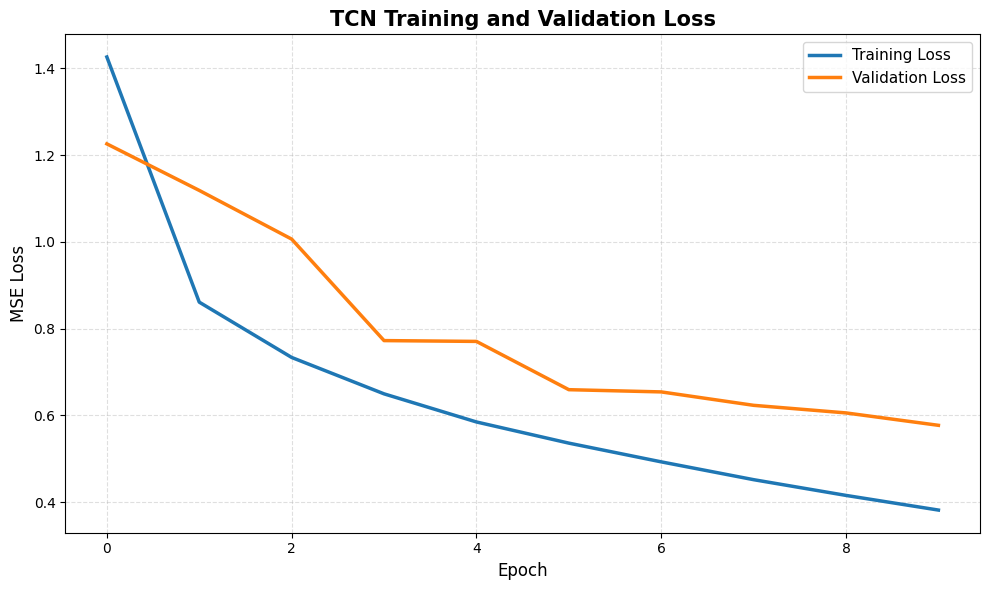

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2.5
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2.5
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("TCN Training and Validation Loss", fontsize=15, fontweight="bold")

plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [16]:
# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Predictions
preds = model.predict(X_test, verbose=0).flatten()

# Evaluations
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2 : {r2:.4f}")


RMSE : 0.7625
MAE  : 0.5814
R2 : 0.7063


In [17]:
# Baseline
baseline_preds = model.predict(
    X_test,
    verbose=0
).flatten()

baseline_r2 = r2_score(
    y_test,
    baseline_preds
)

print("Baseline R²:", baseline_r2)

# Feature Importance
from sklearn.metrics import r2_score

feature_importance = {}

X_test_copy = X_test.copy()

for feature_idx, feature_name in enumerate(feature_cols):

    X_permuted = X_test_copy.copy()

    # Shuffle feature across samples
    shuffled = np.random.permutation(
        X_permuted[:, :, feature_idx]
    )

    X_permuted[:, :, feature_idx] = shuffled

    perm_preds = model.predict(
        X_permuted,
        verbose=0
    ).flatten()

    perm_r2 = r2_score(
        y_test,
        perm_preds
    )

    importance = baseline_r2 - perm_r2

    feature_importance[feature_name] = importance

importance_df = (
    pd.DataFrame(
        feature_importance.items(),
        columns=["Feature", "Importance"]
    )
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(importance_df)


Baseline R²: 0.7063033580780029
                Feature  Importance
12                lag_3    0.546259
10                lag_1    0.427708
13                lag_4    0.254717
2          infection_id    0.218972
11                lag_2    0.151263
3                  year    0.119807
7             longitude    0.058523
8   population_estimate    0.053217
0              state_id    0.048060
6              latitude    0.038529
9                income    0.035181
1             county_id    0.030623
4              week_sin    0.005646
5              week_cos    0.002440


In [18]:
# Getting latitude and longitude importance values
lat_imp = importance_df.loc[
    importance_df["Feature"] == "latitude",
    "Importance"
].values[0]

lon_imp = importance_df.loc[
    importance_df["Feature"] == "longitude",
    "Importance"
].values[0]

# Removing original latitude and longitude rows
importance_df = importance_df[
    ~importance_df["Feature"].isin(["latitude", "longitude"])
].copy()

# Adding Location feature
location_row = pd.DataFrame({
    "Feature": ["Location"],
    "Importance": [lat_imp + lon_imp]
})

importance_df = pd.concat(
    [importance_df, location_row],
    ignore_index=True
)

# Sorting again
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(importance_df)

                Feature  Importance
0                 lag_3    0.546259
1                 lag_1    0.427708
2                 lag_4    0.254717
3          infection_id    0.218972
4                 lag_2    0.151263
5                  year    0.119807
6              Location    0.097052
7   population_estimate    0.053217
8              state_id    0.048060
9                income    0.035181
10            county_id    0.030623
11             week_sin    0.005646
12             week_cos    0.002440


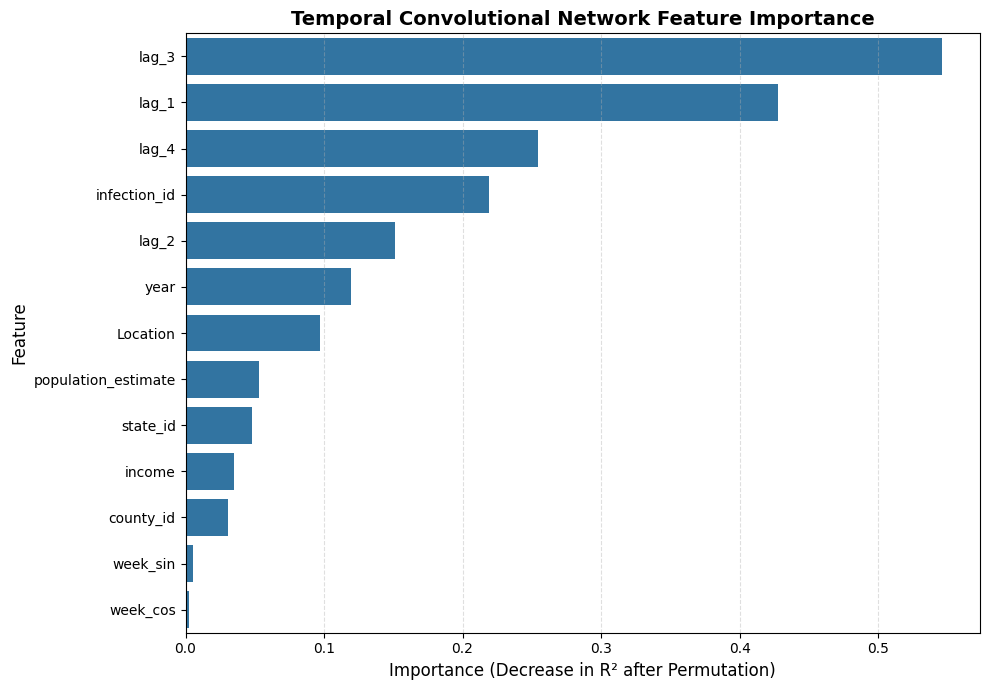

In [19]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for horizontal plotting
plot_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=plot_df,
    x="Importance",
    y="Feature"#,
    #palette="viridis"
)

plt.xlabel(
    "Importance (Decrease in R² after Permutation)",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Temporal Convolutional Network Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()